In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from os.path import exists

sys.path.append('../..')

In [55]:
import numpy as np
from loguru import logger
import pylab as plt

from stable_baselines3 import PPO, DQN

In [49]:
from vimms.Common import POSITIVE, set_log_level_warning, load_obj, save_obj
from vimms.ChemicalSamplers import MZMLFormulaSampler, MZMLRTandIntensitySampler, MZMLChromatogramSampler
from vimms.Noise import UniformSpikeNoise
from vimms.Evaluation import evaluate_real
from vimms.Chemicals import ChemicalMixtureFromMZML
from vimms.Roi import RoiBuilderParams

from vimms.MassSpec import IndependentMassSpectrometer
from vimms.Controller import TopNController, TopN_SmartRoiController, WeightedDEWController
from vimms.Environment import Environment

from mass_spec_utils.data_import.mzmine import load_picked_boxes

from vimms_gym.env import DDAEnv
from vimms_gym.chemicals import generate_chemicals
from vimms_gym.evaluation import evaluate, run_method
from vimms_gym.common import METHOD_PPO, METHOD_DQN, METHOD_TOPN, METHOD_RANDOM, METHOD_FULLSCAN
from vimms_gym.visualisation import plot_N, plot_ms1_ms2_counts, plot_action_hist, plot_action_probs, plot_reward_probs

# 1. Parameters

In [5]:
n_chemicals = (5000, 20000)
mz_range = (70, 1000)
rt_range = (0, 1440)
intensity_range = (1E4, 1E20)

In [6]:
min_mz = mz_range[0]
max_mz = mz_range[1]
min_rt = rt_range[0]
max_rt = rt_range[1]
min_log_intensity = np.log(intensity_range[0])
max_log_intensity = np.log(intensity_range[1])

In [7]:
isolation_window = 0.7
N = 10
rt_tol = 120
small_rt_tol = 15
mz_tol = 10
min_ms1_intensity = 5000
ionisation_mode = POSITIVE

enable_spike_noise = True
noise_density = 0.1
noise_max_val = 1e3

In [8]:
mzml_filename = '../fullscan_QCB.mzML'
samplers = None
samplers_pickle = 'samplers_fullscan_QCB.mzML.p'
if exists(samplers_pickle):
    logger.info('Loaded %s' % samplers_pickle)
    samplers = load_obj(samplers_pickle)
    mz_sampler = samplers['mz']
    ri_sampler = samplers['rt_intensity']
    cr_sampler = samplers['chromatogram']
else:
    logger.info('Creating samplers from %s' % mzml_filename)
    mz_sampler = MZMLFormulaSampler(mzml_filename, min_mz=min_mz, max_mz=max_mz)
    ri_sampler = MZMLRTandIntensitySampler(mzml_filename, min_rt=min_rt, max_rt=max_rt,
                                           min_log_intensity=min_log_intensity,
                                           max_log_intensity=max_log_intensity)
    roi_params = RoiBuilderParams(min_roi_length=3, at_least_one_point_above=1000)
    cr_sampler = MZMLChromatogramSampler(mzml_filename, roi_params=roi_params)
    samplers = {
        'mz': mz_sampler,
        'rt_intensity': ri_sampler,
        'chromatogram': cr_sampler
    }
    save_obj(samplers, samplers_pickle)

2022-05-03 11:28:14.291 | INFO     | __main__:<cell line: 4>:5 - Loaded samplers_fullscan_QCB.mzML.p


In [9]:
params = {
    'chemical_creator': {
        'mz_range': mz_range,
        'rt_range': rt_range,
        'intensity_range': intensity_range,
        'n_chemicals': n_chemicals,
        'mz_sampler': mz_sampler,
        'ri_sampler': ri_sampler,
        'cr_sampler': cr_sampler,
    },
    'noise': {
        'enable_spike_noise': enable_spike_noise,
        'noise_density': noise_density,
        'noise_max_val': noise_max_val,
        'mz_range': mz_range
    },
    'env': {
        'ionisation_mode': ionisation_mode,
        'rt_range': rt_range,
        'isolation_window': isolation_window,
        'mz_tol': mz_tol,
        'rt_tol': rt_tol,
    }
}

In [10]:
max_peaks = 200
in_dir = 'results'

# 2. Evaluation on QCB data

In [12]:
env_name = 'DDAEnv'

In [13]:
eval_dir = 'evaluation_QCB'
methods = [
    METHOD_PPO,
    METHOD_TOPN,
    METHOD_RANDOM,    
]
out_dir = eval_dir
in_dir, out_dir

('results', 'evaluation_QCB')

In [14]:
intensity_threshold = 0.5

#### Load pre-processed QCB chemicals

In [15]:
fullscan_file = '../fullscan_QCB.mzML'

In [16]:
# min_roi_intensity = 0
# min_roi_length = 0

# min_roi_intensity = 500
# min_roi_length = 0
# at_least_one_point_above = 5000

min_roi_intensity = 0
min_roi_length = 3
at_least_one_point_above = 1000

In [17]:
filename = 'datasets_%d_%d_%d.p' % (min_roi_intensity, min_roi_length, at_least_one_point_above)

if exists(filename):
    chemicals = load_obj(filename)
    print(len(chemicals))
else:
    rp = RoiBuilderParams(min_roi_intensity=min_roi_intensity, min_roi_length=min_roi_length, 
                   at_least_one_point_above=at_least_one_point_above)
    cm = ChemicalMixtureFromMZML(fullscan_file, roi_params=rp)
    chemicals = cm.sample(None, 2, source_polarity=ionisation_mode)
    print(len(chemicals))
    save_obj(chemicals, filename)

2022-05-03 11:30:56.437 | DEBUG    | vimms.Chemicals:_extract_rois:638 - Extracted 43107 good ROIs from ../fullscan_QCB.mzML
2022-05-03 11:31:02.468 | INFO     | vimms.Common:save_obj:410 - Saving <class 'list'> to datasets_0_3_1000.p


43107


#### Filter chemicals by mz and RT range

In [18]:
filtered = []
for chem in chemicals:
    if (min_mz < chem.isotopes[0][0] < max_mz) and (min_rt < chem.rt < max_rt):
        filtered.append(chem)
        
len(filtered)

43060

In [19]:
filtered_chem_list = [filtered]

#### Disable spike noise in DDAEnv

In [30]:
params['noise']['enable_spike_noise'] = False
params

{'chemical_creator': {'mz_range': (70, 1000),
  'rt_range': (0, 1440),
  'intensity_range': (10000.0, 1e+20),
  'n_chemicals': (5000, 20000),
  'mz_sampler': <vimms.ChemicalSamplers.MZMLFormulaSampler at 0x1f36ac79c10>,
  'ri_sampler': <vimms.ChemicalSamplers.MZMLRTandIntensitySampler at 0x1f36ac43b80>,
  'cr_sampler': <vimms.ChemicalSamplers.MZMLChromatogramSampler at 0x1f36aba4460>},
 'noise': {'enable_spike_noise': False,
  'noise_density': 0.1,
  'noise_max_val': 1000.0,
  'mz_range': (70, 1000)},
 'env': {'ionisation_mode': 'Positive',
  'rt_range': (0, 1440),
  'isolation_window': 0.7,
  'mz_tol': 10,
  'rt_tol': 120}}

In [12]:
n_eval_episodes = 1
deterministic = True

In [13]:
set_log_level_warning()

1

In [21]:
chem_list = filtered_chem_list

## Run different methods

In [22]:
eval_dir = 'visualisation_QCB'

In [23]:
for chems in chem_list:
    print(len(chems))

43060


In [24]:
max_peaks

200

In [25]:
out_dir = eval_dir
in_dir, out_dir

('results', 'visualisation_QCB')

In [26]:
all_results = {}

In [27]:
env_name = 'DDAEnv'

### Run PPO

In [28]:
method = METHOD_PPO

In [29]:
model_name = 'PPO'

In [42]:
effective_rt_tol = rt_tol
copy_params = dict(params)        
copy_params['env']['rt_tol'] = effective_rt_tol
copy_params

{'chemical_creator': {'mz_range': (70, 1000),
  'rt_range': (0, 1440),
  'intensity_range': (10000.0, 1e+20),
  'n_chemicals': (5000, 20000),
  'mz_sampler': <vimms.ChemicalSamplers.MZMLFormulaSampler at 0x1f36ac79c10>,
  'ri_sampler': <vimms.ChemicalSamplers.MZMLRTandIntensitySampler at 0x1f36ac43b80>,
  'cr_sampler': <vimms.ChemicalSamplers.MZMLChromatogramSampler at 0x1f36aba4460>},
 'noise': {'enable_spike_noise': False,
  'noise_density': 0.1,
  'noise_max_val': 1000.0,
  'mz_range': (70, 1000)},
 'env': {'ionisation_mode': 'Positive',
  'rt_range': (0, 1440),
  'isolation_window': 0.7,
  'mz_tol': 10,
  'rt_tol': 120}}

In [41]:
fname = os.path.join(in_dir, '%s_%s.zip' % (env_name, model_name))
model = PPO.load(fname)

In [33]:
results = run_method(env_name, copy_params, max_peaks, chem_list, method, out_dir, model=model, print_eval=True, print_reward=True)


Episode 0 (43060 chemicals)
steps	 500 	total rewards	 75.81979129173445
steps	 1000 	total rewards	 204.58642550152246
steps	 1500 	total rewards	 339.05444949047137
steps	 2000 	total rewards	 485.2968174385665
steps	 2500 	total rewards	 650.4607962026516
steps	 3000 	total rewards	 791.7883679507332
steps	 3500 	total rewards	 873.8724615150015
steps	 4000 	total rewards	 936.8288914427949
steps	 4500 	total rewards	 981.8031306397697
steps	 5000 	total rewards	 1022.6785689836029
Finished after 5229 timesteps with total reward 1046.6941424144006
{'coverage_prop': '0.058', 'intensity_prop': '0.037', 'ms1/ms2 ratio': '0.605', 'efficiency': '0.773', 'TP': '1103', 'FP': '396', 'FN': '41561', 'precision': '0.736', 'recall': '0.026', 'f1': '0.050'}


In [34]:
ppo_result = results[0]
ppo_result

### Run Top-N

In [35]:
method = METHOD_TOPN

In [43]:
effective_rt_tol = small_rt_tol
copy_params = dict(params)        
copy_params['env']['rt_tol'] = effective_rt_tol
copy_params

{'chemical_creator': {'mz_range': (70, 1000),
  'rt_range': (0, 1440),
  'intensity_range': (10000.0, 1e+20),
  'n_chemicals': (5000, 20000),
  'mz_sampler': <vimms.ChemicalSamplers.MZMLFormulaSampler at 0x1f36ac79c10>,
  'ri_sampler': <vimms.ChemicalSamplers.MZMLRTandIntensitySampler at 0x1f36ac43b80>,
  'cr_sampler': <vimms.ChemicalSamplers.MZMLChromatogramSampler at 0x1f36aba4460>},
 'noise': {'enable_spike_noise': False,
  'noise_density': 0.1,
  'noise_max_val': 1000.0,
  'mz_range': (70, 1000)},
 'env': {'ionisation_mode': 'Positive',
  'rt_range': (0, 1440),
  'isolation_window': 0.7,
  'mz_tol': 10,
  'rt_tol': 15}}

In [44]:
model = None

In [45]:
results = run_method(env_name, copy_params, max_peaks, chem_list, method, out_dir, N=10, model=model, print_eval=True, print_reward=True)


Episode 0 (43060 chemicals)
steps	 500 	total rewards	 27.30326929199802
steps	 1000 	total rewards	 139.49700491833164
steps	 1500 	total rewards	 296.6913507306838
steps	 2000 	total rewards	 438.6002663483516
steps	 2500 	total rewards	 601.5871305063669
steps	 3000 	total rewards	 769.1488547622309
steps	 3500 	total rewards	 881.3372738287152
steps	 4000 	total rewards	 943.6398493611532
steps	 4500 	total rewards	 992.2096734493467
steps	 5000 	total rewards	 1037.6757910434385
steps	 5500 	total rewards	 1063.1430298204623
steps	 6000 	total rewards	 1089.8358846037672
Finished after 6273 timesteps with total reward 1098.7869561970629
{'coverage_prop': '0.074', 'intensity_prop': '0.049', 'ms1/ms2 ratio': '0.173', 'efficiency': '0.596', 'TP': '1355', 'FP': '495', 'FN': '41210', 'precision': '0.732', 'recall': '0.032', 'f1': '0.061'}


In [46]:
topN_result = results[0]
topN_result

# 3. Visualisation

## Visualise some results from the first episode

Limit some plots to the first 1000 steps.

In [47]:
limit = 1000

Plot the distribution of N: the number of MS2 scans that follow an MS1 scan

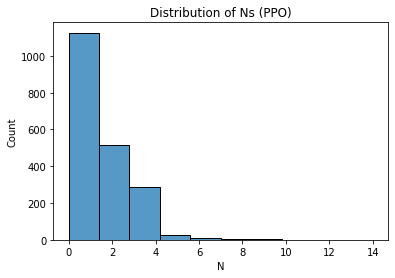

In [50]:
plot_N(ppo_result, bins=10, title='Distribution of Ns (PPO)')

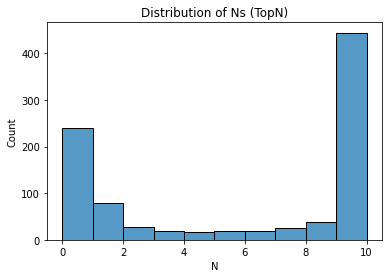

In [51]:
plot_N(topN_result, bins=10, title='Distribution of Ns (TopN)')

Plot the number of MS1 and MS2 scans over time

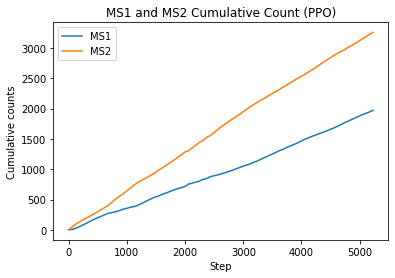

In [52]:
ppo_ms1, ppo_ms2 = plot_ms1_ms2_counts(ppo_result, title='MS1 and MS2 Cumulative Count (PPO)')

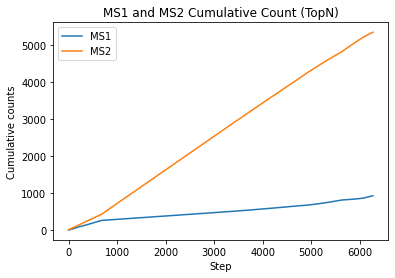

In [53]:
topN_ms1, topN_ms2 = plot_ms1_ms2_counts(topN_result, title='MS1 and MS2 Cumulative Count (TopN)')

Text(0.5, 1.0, 'MS2 Cumulative Counts')

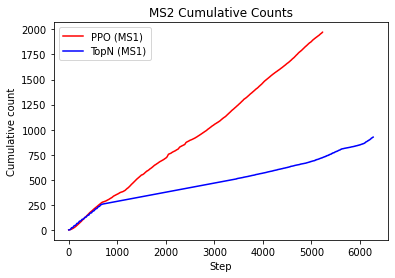

In [56]:
plt.plot(ppo_ms1, 'r-', label='PPO (MS1)')
plt.plot(topN_ms1, 'b-', label='TopN (MS1)')
plt.legend()
plt.ylabel('Cumulative count')
plt.xlabel('Step')
plt.title('MS2 Cumulative Counts')

Plot a histogram of all actions.

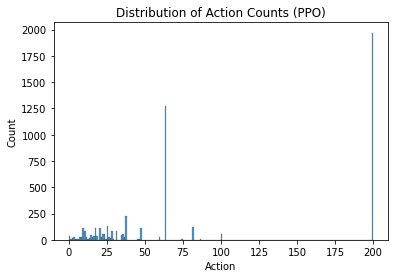

In [57]:
plot_action_hist(ppo_result, bins=200, title='Distribution of Action Counts (PPO)')

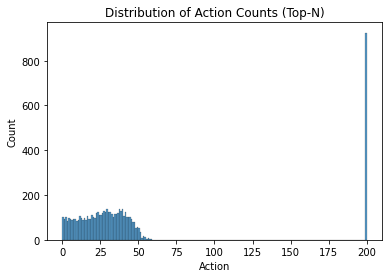

In [58]:
plot_action_hist(topN_result, bins=200, title='Distribution of Action Counts (Top-N)')

Plot a histogram of MS2-actions only

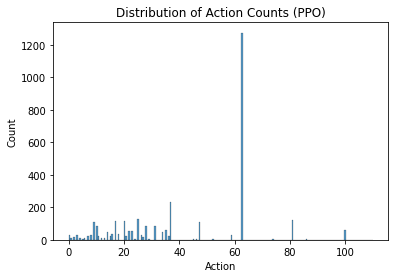

In [59]:
plot_action_hist(ppo_result, ms2_only=True, bins=199, title='Distribution of Action Counts (PPO)')

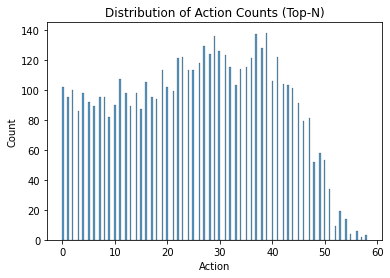

In [60]:
plot_action_hist(topN_result, ms2_only=True, bins=199, title='Distribution of Action Counts (Top-N)')

Show the first few actions

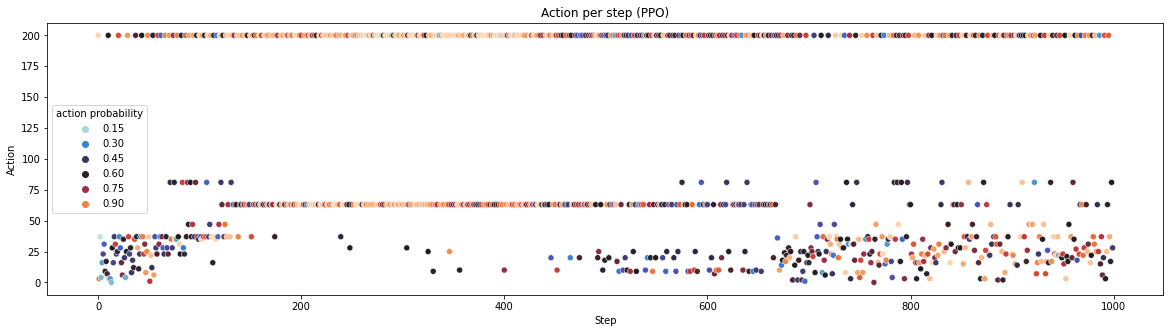

In [61]:
plot_action_probs(ppo_result, limit, max_peaks, title='Action per step (PPO)')

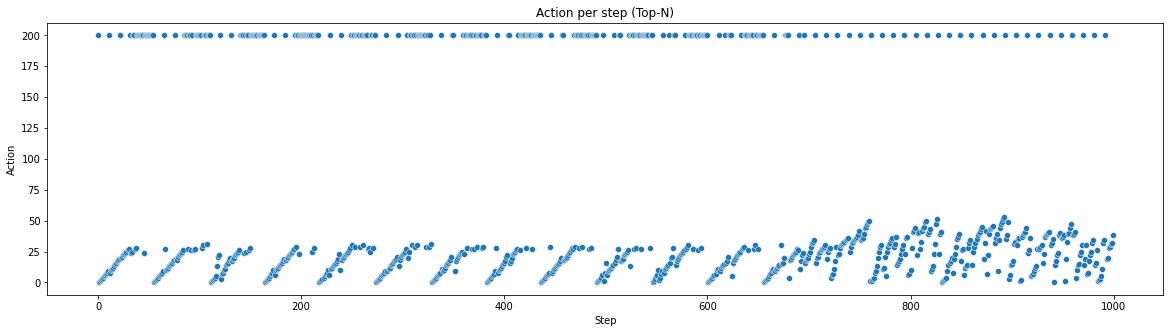

In [62]:
plot_action_probs(topN_result, limit, max_peaks, title='Action per step (Top-N)')

Plot rewards coloured by action probabilities

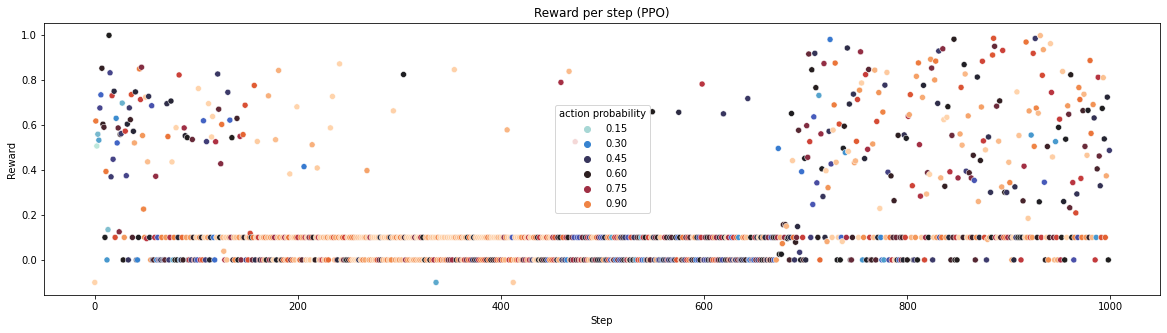

In [63]:
plot_reward_probs(ppo_result, limit, max_peaks, title='Reward per step (PPO)')

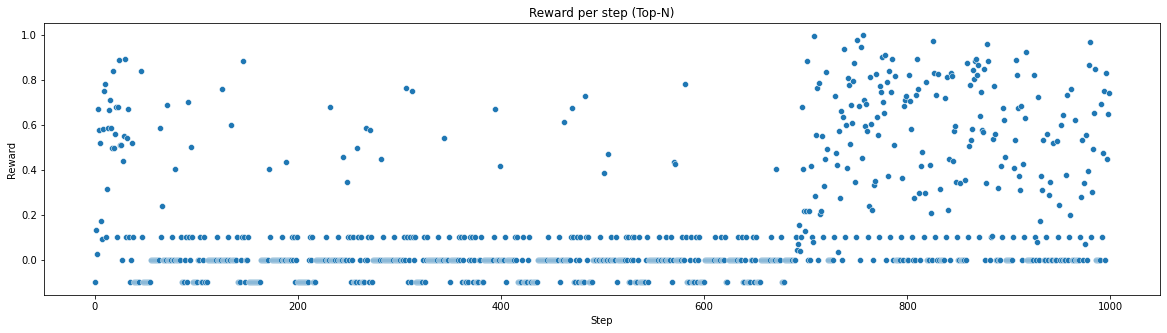

In [64]:
plot_reward_probs(topN_result, limit, max_peaks, title='Reward per step (Top-N)')